# Пример подгрузки данных WeatherBench на суперкомпьютере ВШЭ

Оригинальный формат: для фиксированной сетки на карте (1.40625deg в нашем случае) данные хранятся в формате /10m_u_component_of_wind/10m_u_component_of_wind_1979_1.40625deg.nc (то есть погодная компонента/год) в формате nc. 

Датасет должен отдавать все погодные компоненты для заданного часа в формате numpy. Для этого сделана функция custom_np_load, принимающая путь до фейкового (ненастоящего) файла в формате: "2000-0001.npy", где 2000 - год, 0001 - номер часа в этом году. 

Функция подгрузки (custom_np_load): открывает файл из оригинального формата nc и подгружает данные за определенный день (возможно, реализация не топовая с точки зрения эффективности, но здесь стоило так сделать для удобства подгрузки в даталоадер, тк ему нужно выдавать данные по часам)

Для некоторых погодных перменных есть 13 вариантов (на разных уровнях атмосферного давления), на некоторых только 1 вариант - это отражает ids (поэтому там иногда на 1 возрастает, иногда на 13). Про это хорошо рассказано вот тут https://github.com/black-yt/WeatherGFT/tree/main/Data 

In [ ]:
!pip install torch
!pip install pandas
!pip install numpy 
!pip install h5netcdf

In [1]:
import os
import numpy as np
import torch
import pandas as pd
import h5netcdf
from torch.utils.data import Dataset, DataLoader

In [3]:
def custom_np_load(file_path):
    input_folder = '/home/fratnikov/weather_bench/1.40625deg/'
    match_set = {
            '2m_temperature': 't2m', 
            '10m_u_component_of_wind': 'u10', 
            '10m_v_component_of_wind': 'v10', 
            'total_cloud_cover': 'tcc', 
            'total_precipitation': 'tp', 
            'toa_incident_solar_radiation': 'tisr', 
            'geopotential': 'z', 
            'temperature': 't',
            'specific_humidity': 'q', 
            'relative_humidity' : 'r', 
            'u_component_of_wind': 'u', 
            'v_component_of_wind': 'v', 
            'vorticity': 'vo', 
            'potential_vorticity': 'pv'
    }

    ids = [0, 1, 2, 3, 4, 5, 6, 19, 32, 45, 58, 71, 84, 97, 110]
    year = file_path.split("/")[-1][0:4]
    hour = int(file_path.split("/")[-1][5:9])
    
    match_set_files = {}
    for key in match_set: 
        path = input_folder + key + '/' + key + '_' + year + '_1.40625deg.nc'
        match_set_files[key] = h5netcdf.File(path, 'r')

    res = np.zeros([110, 128, 256])

    for ind, key in enumerate(match_set): 
        start_id = ids[ind]
        end_id = ids[ind + 1]
                    
        if end_id - start_id == 1:
            res[start_id, :, :] = match_set_files[key][match_set[key]][hour, :, :]
        else:
            res[start_id:end_id, :, :] = match_set_files[key][match_set[key]][hour, 0:13, :, :]

    for key in match_set: 
        match_set_files[key].close()

    return res

### Датасет (из WeatherGFT)

Настроенный датасет, принимает стартовое и финальное время, датасет выдает пары x - состояние в стартовое время и y - тензор на одно измерение больше из нескольких состояний в моменты [start_time + lead_time, start_time + 2 * lead_time, ..., start_time + (multi_target_steps - 1) * lead_time]

Следующий батч начинается с момента start_time + inverval. 

Важно - используется файлик со статистиками для нормализации, лежит по адресу "/home/epbugaev/weather_bench/1.40625deg/mean_std.npy"

In [6]:
class WeatherBench128(Dataset):
    def __init__(self, 
                 start_time: str='2000-01-01 00:00:00', 
                 end_time: str='2000-01-05 23:00:00',
                 include_target: bool=False,
                 lead_time: int=1, 
                 interval: int=6,
                 muti_target_steps: int=6):
        
        self.variables_list = [
        0, 1, 2, 4 ,
        6 ,7 ,8 ,9 ,10,11,12,13,14,15,16,17,18,
        19,20,21,22,23,24,25,26,27,28,29,30,31,
        45,46,47,48,49,50,51,52,53,54,55,56,57,
        58,59,60,61,62,63,64,65,66,67,68,69,70,
        71,72,73,74,75,76,77,78,79,80,81,82,83]
        self.data_folder = '/home/fratnikov/weather_bench/npy/1.40625deg/'
        self.start_time = start_time
        self.end_time = end_time
        self.include_target = include_target
        self.lead_time = lead_time
        self.interval = interval
        self.muti_target_steps = muti_target_steps
        self.init_time_list()
        self.init_file_list()
        self.get_mean_std()
        self.length = len(self.x_time_ilst)


    def init_time_list(self):
        if self.include_target:
            target_end_time = pd.to_datetime(self.end_time)
            input_end_time = target_end_time - pd.Timedelta(hours=self.muti_target_steps*self.lead_time)
            input_end_time_str = input_end_time.strftime('%Y-%m-%d %H:%M:%S')
            self.x_time_ilst = pd.date_range(self.start_time, input_end_time_str, freq=str(self.interval)+'h')
        else:
            self.x_time_ilst = pd.date_range(self.start_time, self.end_time, freq=str(self.interval)+'h')


    def idx_in_year(self, time_stamp):
        year = time_stamp.year
        first_day = pd.to_datetime(f'{year}-01-01 00:00:00')
        idx = int((time_stamp - first_day).total_seconds() / 3600)
        return idx
    

    def init_file_list(self):
        self.x_file_list = [os.path.join(self.data_folder,
                                        str(time_stamp.year)+'-{:04d}'.format(self.idx_in_year(time_stamp))+'.npy')
                                        for time_stamp in self.x_time_ilst]
        

    def get_mean_std(self):
        mean_std = np.load("/home/epbugaev/weather_bench/1.40625deg/mean_std.npy")
        self.the_mean = mean_std[0]
        self.the_std = mean_std[1]
        self.data_mean_tensor = torch.from_numpy(self.the_mean[self.variables_list]).float()
        self.data_std_tensor = torch.from_numpy(self.the_std[self.variables_list]).float()

   
    def normalization(self, sample):
        return (sample[self.variables_list] - self.the_mean[self.variables_list, None, None]) / self.the_std[self.variables_list, None, None]

    def __len__(self):
        return self.length

    def __getitem__(self, index):
        file_path = self.x_file_list[index]
        sample_x = custom_np_load(file_path)
        sample_x = self.normalization(sample_x)
        sample_x = torch.from_numpy(sample_x).float()
        
        y_list = []
        x_time = self.x_time_ilst[index]
        for steps in range(self.muti_target_steps):
            y_time = x_time + pd.Timedelta(hours=(steps+1)*self.lead_time)
            y_file_path = os.path.join(self.data_folder, 
                                       str(y_time.year)+'-{:04d}'.format(self.idx_in_year(y_time))+'.npy')
            sample_y = custom_np_load(y_file_path)
            sample_y = self.normalization(sample_y)
            sample_y = torch.from_numpy(sample_y).float()
            y_list.append(sample_y)

        if self.muti_target_steps > 1:
            sample_y_all = torch.stack(y_list, dim=0)
        else:
            sample_y_all = y_list[0]
            
        return sample_x, sample_y_all


### Новая версия 

In [2]:
import os
import numpy as np
import torch
import pandas as pd
import h5netcdf
from torch.utils.data import Dataset, DataLoader


def custom_np_load(file_path):
    input_folder = '/home/fratnikov/weather_bench/1.40625deg/'
    match_set = {
            '2m_temperature': 't2m', 
            '10m_u_component_of_wind': 'u10', 
            '10m_v_component_of_wind': 'v10', 
            'total_cloud_cover': 'tcc', 
            'total_precipitation': 'tp', 
            'toa_incident_solar_radiation': 'tisr', 
            'geopotential': 'z', 
            'temperature': 't',
            'specific_humidity': 'q', 
            'relative_humidity' : 'r', 
            'u_component_of_wind': 'u', 
            'v_component_of_wind': 'v', 
            'vorticity': 'vo', 
            'potential_vorticity': 'pv'
    }

    ids = [0, 1, 2, 3, 4, 5, 6, 19, 32, 45, 58, 71, 84, 97, 110]
    year = file_path.split("/")[-1][0:4]
    hour = int(file_path.split("/")[-1][5:9])
    
    match_set_files = {}
    for key in match_set: 
        path = input_folder + key + '/' + key + '_' + year + '_1.40625deg.nc'
        match_set_files[key] = h5netcdf.File(path, 'r')

    res = np.zeros([110, 128, 256])

    for ind, key in enumerate(match_set): 
        start_id = ids[ind]
        end_id = ids[ind + 1]
                    
        if end_id - start_id == 1:
            res[start_id, :, :] = match_set_files[key][match_set[key]][hour, :, :]
        else:
            res[start_id:end_id, :, :] = match_set_files[key][match_set[key]][hour, 0:13, :, :]

    for key in match_set: 
        match_set_files[key].close()

    return res


class WeatherBench128(Dataset):
    def __init__(self, 
                 start_time: str='2000-01-01 00:00:00', 
                 end_time: str='2000-01-05 23:00:00',
                 include_target: bool=False,
                 lead_time: int=6, 
                 interval: int=6,
                 muti_target_steps: int=1,
                 # New parameters for time sequences
                 start_time_x: int=0,
                 end_time_x: int=1,
                 start_time_y: int=0,
                 end_time_y: int=1):
        
        self.variables_list = [
        0, 1, 2, 4 ,
        6 ,7 ,8 ,9 ,10,11,12,13,14,15,16,17,18,
        19,20,21,22,23,24,25,26,27,28,29,30,31,
        45,46,47,48,49,50,51,52,53,54,55,56,57,
        58,59,60,61,62,63,64,65,66,67,68,69,70,
        71,72,73,74,75,76,77,78,79,80,81,82,83]
        self.data_folder = '/home/fratnikov/weather_bench/npy/1.40625deg/' #"/home/fa.buzaev/data_to_egor"
        self.start_time = start_time
        self.end_time = end_time
        self.include_target = include_target
        self.lead_time = lead_time
        self.interval = interval
        self.muti_target_steps = muti_target_steps
        
        # Store the new sequence parameters
        self.start_time_x = start_time_x
        self.end_time_x = end_time_x
        self.start_time_y = start_time_y
        self.end_time_y = end_time_y
        
        # +1 because the ranges are now inclusive
        self.x_sequence_length = end_time_x - start_time_x + 1
        self.y_sequence_length = end_time_y - start_time_y + 1
        
        if self.x_sequence_length <= 0:
            raise ValueError("end_time_x must be greater than or equal to start_time_x")
        if self.y_sequence_length <= 0:
            raise ValueError("end_time_y must be greater than or equal to start_time_y")
            
        self.init_time_list()
        self.init_file_list()
        self.get_mean_std()
        # Update the length calculation to account for inclusive ranges
        self.length = len(self.x_time_ilst) - max(self.end_time_x, self.end_time_y + self.muti_target_steps * self.lead_time // self.interval)
        if self.length <= 0:
            raise ValueError("Not enough time steps available for the requested sequence lengths")


    def init_time_list(self):
        if self.include_target:
            target_end_time = pd.to_datetime(self.end_time)
            input_end_time = target_end_time - pd.Timedelta(hours=self.muti_target_steps*self.lead_time)
            input_end_time_str = input_end_time.strftime('%Y-%m-%d %H:%M:%S')
            self.x_time_ilst = pd.date_range(self.start_time, input_end_time_str, freq=str(self.interval)+'h')
        else:
            self.x_time_ilst = pd.date_range(self.start_time, self.end_time, freq=str(self.interval)+'h')


    def idx_in_year(self, time_stamp):
        year = time_stamp.year
        first_day = pd.to_datetime(f'{year}-01-01 00:00:00')
        idx = int((time_stamp - first_day).total_seconds() / 3600)
        return idx
    

    def init_file_list(self):
        # your_weatherbench_data_path/1979/1979-0000.npy
        self.x_file_list= [os.path.join(self.data_folder, #str(time_stamp.year),
                                        str(time_stamp.year)+'-{:04d}'.format(self.idx_in_year(time_stamp))+'.npy')
                                        for time_stamp in self.x_time_ilst]
        

    def get_mean_std(self):
        mean_std = np.load("/home/epbugaev/weather_bench/1.40625deg/mean_std.npy")
        # mean_std = np.ones([2, 110]) # Test
        self.the_mean = mean_std[0]
        self.the_std = mean_std[1]
        self.data_mean_tensor = torch.from_numpy(self.the_mean[self.variables_list]).float()
        self.data_std_tensor = torch.from_numpy(self.the_std[self.variables_list]).float()

   
    def normalization(self, sample):
        return (sample[self.variables_list] - self.the_mean[self.variables_list, None, None]) / self.the_std[self.variables_list, None, None]

    def __len__(self):
        return self.length

    def __getitem__(self, index):
        # Load a sequence of X inputs
        x_sequence = []
        for i in range(self.start_time_x, self.end_time_x + 1):
            current_index = index + i
            file_path = self.x_file_list[current_index]
            sample_x = custom_np_load(file_path)
            sample_x = self.normalization(sample_x)
            sample_x = torch.from_numpy(sample_x).float()
            x_sequence.append(sample_x)
        
        # Stack X sequence
        sample_x_sequence = torch.stack(x_sequence, dim=0)  # [T, C, H, W]
        
        # Load a sequence of Y targets
        y_sequences = []
        for steps in range(self.muti_target_steps):
            y_sequence = []
            for i in range(self.start_time_y, self.end_time_y + 1):
                # Calculate the corresponding time for this target
                x_time = self.x_time_ilst[index + i]
                y_time = x_time + pd.Timedelta(hours=(steps+1)*self.lead_time)
                y_file_path = os.path.join(self.data_folder,
                                          str(y_time.year)+'-{:04d}'.format(self.idx_in_year(y_time))+'.npy')
                sample_y = custom_np_load(y_file_path)
                sample_y = self.normalization(sample_y)
                sample_y = torch.from_numpy(sample_y).float()
                y_sequence.append(sample_y)
            
            # Stack this target sequence
            stacked_y_sequence = torch.stack(y_sequence, dim=0)  # [T, C, H, W]
            y_sequences.append(stacked_y_sequence)
        
        if self.muti_target_steps > 1:
            # Shape: [muti_target_steps, T, C, H, W]
            sample_y_all = torch.stack(y_sequences, dim=0)
        else:
            # Shape: [T, C, H, W]
            sample_y_all = y_sequences[0]
            
        return sample_x_sequence, sample_y_all


# if __name__ == '__main__':
#     train_data = WeatherBench128(start_time='2010-01-01 00:00:00', 
#                                 end_time='2010-03-10 23:00:00',
#                                 include_target=False,
#                                 lead_time=1, 
#                                 interval=1,  # Changed from 6 to 1 hour
#                                 muti_target_steps=1,
#                                 start_time_x=0,
#                                 end_time_x=11,  # Changed to get times 00:00, 00:01, 00:02, 00:03
#                                 start_time_y=12,
#                                 end_time_y=23)  # Changed to get times 00:04, 00:05, 00:06, 00:07
#     # 240h 40input 10batch
    
#     # Debug prints
#     print(f"start_time_x: {train_data.start_time_x}, end_time_x: {train_data.end_time_x}")
#     print(f"X sequence length: {train_data.x_sequence_length}")
#     print(f"start_time_y: {train_data.start_time_y}, end_time_y: {train_data.end_time_y}")
#     print(f"Y sequence length: {train_data.y_sequence_length}")
    
#     # Print the range that's actually used in the loop (now inclusive)
#     print("X indices:", list(range(train_data.start_time_x, train_data.end_time_x + 1)))
#     print("Y indices:", list(range(train_data.start_time_y, train_data.end_time_y + 1)))
    
#     # Print the actual timestamps for X and Y
#     print("\nActual timestamps for X:")
#     for i in range(train_data.start_time_x, train_data.end_time_x + 1):
#         print(f"  Index {i}: {train_data.x_time_ilst[i]}")
    
#     print("\nActual timestamps for Y:")
#     for i in range(train_data.start_time_y, train_data.end_time_y + 1):
#         print(f"  Index {i}: {train_data.x_time_ilst[i]}")
    
#     train_loader = DataLoader(train_data, batch_size=5, shuffle=False, num_workers=8)  # Changed batch_size to 5
#     print("\nbatch len:", len(train_loader))

#     for batch_idx, (X, Y) in enumerate(train_loader):
#         print("batch", batch_idx)
#         print("X shape:", X.shape)
#         print("Y shape:", Y.shape)
        
#         # Проверяем первый батч более детально
#         if batch_idx == 0:
#             print("\nПроверка первого батча:")
#             for b in range(X.shape[0]):
#                 print(f"  Пример {b} в батче:")
#                 print(f"    Временные метки X должны быть: {train_data.x_time_ilst[b:b+4]}")
#                 print(f"    Временные метки Y должны быть: {train_data.x_time_ilst[b+4:b+8]}")
#             break

In [14]:
import os
import numpy as np
import torch
import pandas as pd
import h5netcdf
from torch.utils.data import Dataset, DataLoader


class WeatherBench128New(Dataset):
    def __init__(self, 
                 start_time: str='2000-01-01 00:00:00', 
                 end_time: str='2000-01-05 23:00:00',
                 include_target: bool=False,
                 lead_time: int=6, 
                 interval: int=6,
                 muti_target_steps: int=1,
                 # New parameters for time sequences
                 start_time_x: int=0,
                 end_time_x: int=1,
                 start_time_y: int=0,
                 end_time_y: int=1, 
                 cut=None, 
                 num_preload=1):
        
        self.variables_list = [
        0, 1, 2, 4 ,
        6 ,7 ,8 ,9 ,10,11,12,13,14,15,16,17,18,
        19,20,21,22,23,24,25,26,27,28,29,30,31,
        45,46,47,48,49,50,51,52,53,54,55,56,57,
        58,59,60,61,62,63,64,65,66,67,68,69,70,
        71,72,73,74,75,76,77,78,79,80,81,82,83]
        self.data_folder = '/home/fratnikov/weather_bench/npy/1.40625deg/' #"/home/fa.buzaev/data_to_egor"
        self.start_time = start_time
        self.end_time = end_time
        self.include_target = include_target
        self.lead_time = lead_time
        self.interval = interval
        self.muti_target_steps = muti_target_steps
        
        # Store the new sequence parameters
        self.start_time_x = start_time_x
        self.end_time_x = end_time_x
        self.start_time_y = start_time_y
        self.end_time_y = end_time_y
        
        # +1 because the ranges are now inclusive
        self.x_sequence_length = end_time_x - start_time_x + 1
        self.y_sequence_length = end_time_y - start_time_y + 1
        
        if self.x_sequence_length <= 0:
            raise ValueError("end_time_x must be greater than or equal to start_time_x")
        if self.y_sequence_length <= 0:
            raise ValueError("end_time_y must be greater than or equal to start_time_y")
            
        self.init_time_list()
        self.init_file_list()
        self.get_mean_std()
        # Update the length calculation to account for inclusive ranges
        self.length = len(self.x_time_ilst) - max(self.end_time_x, self.end_time_y + self.muti_target_steps * self.lead_time // self.interval)
        
        print('x length:', len(self.x_time_ilst), 'something:', max(self.end_time_x, self.end_time_y + self.muti_target_steps * self.lead_time // self.interval))
        if self.length <= 0:
            raise ValueError("Not enough time steps available for the requested sequence lengths")
        

        self.cut = cut
        self.preload = {}
        self.num_preload = num_preload
        
        self.hit = 0
        self.not_hit = 0


    def custom_np_load(self, file_path):
        input_folder = '/home/fratnikov/weather_bench/1.40625deg/'
        match_set = {
                '2m_temperature': 't2m', 
                '10m_u_component_of_wind': 'u10', 
                '10m_v_component_of_wind': 'v10', 
                'total_cloud_cover': 'tcc', 
                'total_precipitation': 'tp', 
                'toa_incident_solar_radiation': 'tisr', 
                'geopotential': 'z', 
                'temperature': 't',
                'specific_humidity': 'q', 
                'relative_humidity' : 'r', 
                'u_component_of_wind': 'u', 
                'v_component_of_wind': 'v', 
                'vorticity': 'vo', 
                'potential_vorticity': 'pv'
        }

        ids = [0, 1, 2, 3, 4, 5, 6, 19, 32, 45, 58, 71, 84, 97, 110]
        year = file_path.split("/")[-1][0:4]
        hour = int(file_path.split("/")[-1][5:9])

        if self.preload is not None and (year + '-' + str(hour)) in self.preload: # If already loaded, do not load again
            #print('hit!')
            self.hit += 1
            return self.preload[year + '-' + str(hour)]
        else:
            #print('reading, not found:', (year + '-' + str(hour)))
            self.not_hit += 1
            self.preload = {}

        match_set_files = {}
        for key in match_set: 
            path = input_folder + key + '/' + key + '_' + year + '_1.40625deg.nc'
            match_set_files[key] = h5netcdf.File(path, 'r')

        

        right_bound_hours = max(hour + 1, min(7861, hour + self.num_preload))

        res = np.zeros([right_bound_hours - hour, 110, 128, 256])

        for ind, key in enumerate(match_set): 
            start_id = ids[ind]
            end_id = ids[ind + 1]

            if end_id - start_id == 1:
                res[:, start_id, :, :] = match_set_files[key][match_set[key]][hour:right_bound_hours, :, :]
            else:
                res[:, start_id:end_id, :, :] = match_set_files[key][match_set[key]][hour:right_bound_hours, 0:13, :, :]

        for cur_hour in range(hour, right_bound_hours): 
            # print('saved:', (year + '-' + str(cur_hour)))
            self.preload[year + '-' + str(cur_hour)] = res[cur_hour - hour, ...]

        for key in match_set: 
            match_set_files[key].close()

        return self.preload[year + '-' + str(hour)]
    

    def init_time_list(self):
        if self.include_target:
            target_end_time = pd.to_datetime(self.end_time)
            input_end_time = target_end_time - pd.Timedelta(hours=self.muti_target_steps*self.lead_time)
            input_end_time_str = input_end_time.strftime('%Y-%m-%d %H:%M:%S')
            self.x_time_ilst = pd.date_range(self.start_time, input_end_time_str, freq=str(self.interval)+'h')
        else:
            self.x_time_ilst = pd.date_range(self.start_time, self.end_time, freq=str(self.interval)+'h')


    def idx_in_year(self, time_stamp):
        year = time_stamp.year
        first_day = pd.to_datetime(f'{year}-01-01 00:00:00')
        idx = int((time_stamp - first_day).total_seconds() / 3600)
        return idx
    

    def init_file_list(self):
        # your_weatherbench_data_path/1979/1979-0000.npy
        self.x_file_list= [os.path.join(self.data_folder, #str(time_stamp.year),
                                        str(time_stamp.year)+'-{:04d}'.format(self.idx_in_year(time_stamp))+'.npy')
                                        for time_stamp in self.x_time_ilst]
        

    def get_mean_std(self):
        mean_std = np.load("/home/epbugaev/weather_bench/1.40625deg/mean_std.npy")
        # mean_std = np.ones([2, 110]) # Test
        self.the_mean = mean_std[0]
        self.the_std = mean_std[1]
        self.data_mean_tensor = torch.from_numpy(self.the_mean[self.variables_list]).float()
        self.data_std_tensor = torch.from_numpy(self.the_std[self.variables_list]).float()

   
    def normalization(self, sample):
        return (sample[self.variables_list] - self.the_mean[self.variables_list, None, None]) / self.the_std[self.variables_list, None, None]

    def __len__(self):
        return self.length

    def __getitem__(self, index):
        # Load a sequence of X inputs
        x_sequence = []
        for i in range(self.start_time_x, self.end_time_x + 1):
            current_index = index + i
            file_path = self.x_file_list[current_index]
            sample_x = self.custom_np_load(file_path)
            sample_x = self.normalization(sample_x)
            sample_x = torch.from_numpy(sample_x).float()

            if self.cut is not None:
                sample_x = sample_x[..., self.cut[0][0]:self.cut[0][1], self.cut[1][0]:self.cut[1][1]]

            x_sequence.append(sample_x)

        # Stack X sequence
        sample_x_sequence = torch.stack(x_sequence, dim=0)  # [T, C, H, W]
        
        # Load a sequence of Y targets
        y_sequences = []
        for steps in range(self.muti_target_steps):
            y_sequence = []
            for i in range(self.start_time_y, self.end_time_y + 1):
                # Calculate the corresponding time for this target
                x_time = self.x_time_ilst[index + i]
                y_time = x_time + pd.Timedelta(hours=(steps+1)*self.lead_time)
                y_file_path = os.path.join(self.data_folder,
                                          str(y_time.year)+'-{:04d}'.format(self.idx_in_year(y_time))+'.npy')
                sample_y = self.custom_np_load(y_file_path)
                sample_y = self.normalization(sample_y)
                sample_y = torch.from_numpy(sample_y).float()

                if self.cut is not None:
                    sample_y = sample_y[..., self.cut[0][0]:self.cut[0][1], self.cut[1][0]:self.cut[1][1]]
                    
                y_sequence.append(sample_y)
            
            # Stack this target sequence
            stacked_y_sequence = torch.stack(y_sequence, dim=0)  # [T, C, H, W]
            y_sequences.append(stacked_y_sequence)
        
        if self.muti_target_steps > 1:
            # Shape: [muti_target_steps, T, C, H, W]
            sample_y_all = torch.stack(y_sequences, dim=0)
        else:
            # Shape: [T, C, H, W]
            sample_y_all = y_sequences[0]
            
        # self.preload = {}
        return sample_x_sequence, sample_y_all

### Пример работы

In [28]:
%%time

train_data_A = WeatherBench128(start_time='2000-12-29 00:00:00', 
                                end_time='2001-01-5 15:00:00',
                                start_time_x = 0,
                                end_time_x = 12,
                                start_time_y = 13,
                                end_time_y = 24,
                                include_target=False,
                                lead_time=1, 
                                interval=1,
                                muti_target_steps=1)

train_loader_A = DataLoader(train_data_A, batch_size=1, shuffle=False, num_workers=8)
X, Y = next(iter(train_loader_A))

CPU times: user 135 ms, sys: 332 ms, total: 467 ms
Wall time: 6.36 s


In [27]:
%%time

train_data = WeatherBench128New(start_time='2000-12-29 00:00:00', 
                                end_time='2001-01-5 15:00:00',
                                start_time_x = 0,
                                end_time_x = 12,
                                start_time_y = 13,
                                end_time_y = 24,
                                include_target=False,
                                lead_time=1, 
                                interval=1,
                                muti_target_steps=1, 
                                num_preload=24)

train_loader_B = DataLoader(train_data, batch_size=1, shuffle=False, num_workers=8)
X_new, Y_new = next(iter(train_loader_B))

x length: 184 something: 25
CPU times: user 162 ms, sys: 179 ms, total: 341 ms
Wall time: 9.64 s


In [19]:
print(train_loader_B.dataset.hit, train_loader_B.dataset.not_hit)

0 0


In [29]:
cnt = 0

b = iter(train_loader_B)
for X, Y in train_loader_A:        
    cnt += 1
    X_new, Y_new = next(b)
    
    if (torch.max(X - X_new) != 0.0 or torch.max(Y - Y_new) != 0.0):
        print(torch.max(X - X_new), torch.max(Y - Y_new), 'cnt:', cnt)
        print('wrong!')
        break
              
    if cnt % 5 == 0:
        print(cnt)

5
10
15
20
25
30
35
40
45
50
55
60
65
70
75
80
85
90
95
100
105
110
115
120
125
130
135
140
145
150
155


In [21]:
%%time 

cnt = 0
for X, Y in train_loader_A:        
    cnt += 1
    if cnt % 5 == 0:
        print(cnt)

5
10
15
20
25
30
35
40
45
50
55
60
65
70
75
80
85
CPU times: user 155 ms, sys: 3.62 s, total: 3.78 s
Wall time: 29.1 s


In [24]:
%%time 

cnt = 0
for X, Y in train_loader_B:        
    cnt += 1
    if cnt % 5 == 0:
        print(cnt)

5
10
15
20
25
30
35
40
45
50
55
60
65
70
75
80
85
CPU times: user 1min 58s, sys: 1min 12s, total: 3min 10s
Wall time: 1min 33s


In [25]:
print(train_loader_B.dataset.hit, train_loader_B.dataset.not_hit)

2024 176


### Уменьшим размеры карты

In [ ]:
class WeatherBench128(Dataset):
    def __init__(self, 
                 start_time: str='2000-01-01 00:00:00', 
                 end_time: str='2000-01-05 23:00:00',
                 include_target: bool=False,
                 lead_time: int=1, 
                 interval: int=6,
                 muti_target_steps: int=6, 
                 cut=None):
        
        self.variables_list = [
        0, 1, 2, 4 ,
        6 ,7 ,8 ,9 ,10,11,12,13,14,15,16,17,18,
        19,20,21,22,23,24,25,26,27,28,29,30,31,
        45,46,47,48,49,50,51,52,53,54,55,56,57,
        58,59,60,61,62,63,64,65,66,67,68,69,70,
        71,72,73,74,75,76,77,78,79,80,81,82,83]
        self.data_folder = '/home/fratnikov/weather_bench/npy/1.40625deg/'
        self.start_time = start_time
        self.end_time = end_time
        self.include_target = include_target
        self.lead_time = lead_time
        self.interval = interval
        self.muti_target_steps = muti_target_steps
        self.init_time_list()
        self.init_file_list()
        self.get_mean_std()
        self.length = len(self.x_time_ilst)
        
        self.cut = cut


    def init_time_list(self):
        if self.include_target:
            target_end_time = pd.to_datetime(self.end_time)
            input_end_time = target_end_time - pd.Timedelta(hours=self.muti_target_steps*self.lead_time)
            input_end_time_str = input_end_time.strftime('%Y-%m-%d %H:%M:%S')
            self.x_time_ilst = pd.date_range(self.start_time, input_end_time_str, freq=str(self.interval)+'h')
        else:
            self.x_time_ilst = pd.date_range(self.start_time, self.end_time, freq=str(self.interval)+'h')


    def idx_in_year(self, time_stamp):
        year = time_stamp.year
        first_day = pd.to_datetime(f'{year}-01-01 00:00:00')
        idx = int((time_stamp - first_day).total_seconds() / 3600)
        return idx
    

    def init_file_list(self):
        self.x_file_list = [os.path.join(self.data_folder,
                                        str(time_stamp.year)+'-{:04d}'.format(self.idx_in_year(time_stamp))+'.npy')
                                        for time_stamp in self.x_time_ilst]
        

    def get_mean_std(self):
        mean_std = np.load("/home/epbugaev/weather_bench/1.40625deg/mean_std.npy")
        self.the_mean = mean_std[0]
        self.the_std = mean_std[1]
        self.data_mean_tensor = torch.from_numpy(self.the_mean[self.variables_list]).float()
        self.data_std_tensor = torch.from_numpy(self.the_std[self.variables_list]).float()

   
    def normalization(self, sample):
        return (sample[self.variables_list] - self.the_mean[self.variables_list, None, None]) / self.the_std[self.variables_list, None, None]

    def __len__(self):
        return self.length

    def __getitem__(self, index):
        file_path = self.x_file_list[index]
        sample_x = custom_np_load(file_path)
        sample_x = self.normalization(sample_x)
        sample_x = torch.from_numpy(sample_x).float()
        
        if self.cut is not None:
            sample_x = sample_x[..., self.cut[0][0]:self.cut[0][1], self.cut[1][0]:self.cut[1][1]]
            
        y_list = []
        x_time = self.x_time_ilst[index]
        for steps in range(self.muti_target_steps):
            y_time = x_time + pd.Timedelta(hours=(steps+1)*self.lead_time)
            y_file_path = os.path.join(self.data_folder, 
                                       str(y_time.year)+'-{:04d}'.format(self.idx_in_year(y_time))+'.npy')
            sample_y = custom_np_load(y_file_path)
            sample_y = self.normalization(sample_y)
            sample_y = torch.from_numpy(sample_y).float()
            
            if self.cut is not None:
                sample_y = sample_y[..., self.cut[0][0]:self.cut[0][1], self.cut[1][0]:self.cut[1][1]]
            
            y_list.append(sample_y)

        if self.muti_target_steps > 1:
            sample_y_all = torch.stack(y_list, dim=0)
        else:
            sample_y_all = y_list[0]
            
        return sample_x, sample_y_all


In [ ]:
train_data = WeatherBench128(start_time='2000-01-01 00:00:00', 
                                end_time='2000-04-15 23:00:00',
                                include_target=False,
                                lead_time=6, 
                                interval=6,
                                muti_target_steps=4, 
                                cut=[[128 - 95, 128 - 60], [256 - 144, 256 - 54]])
# 240h 40 input 10 batch

train_loader = DataLoader(train_data, batch_size=1, shuffle=False, num_workers=8)

all_X = []

for batch_idx, (X, Y) in enumerate(train_loader):
    #print("batch", batch_idx)

    all_X.append(torch.clone(X)) 
    
    #print("X")
    #print(X.shape)

    #print("Y")
    #print(Y.shape)

    #if batch_idx == 1:
    #    break


In [ ]:
import matplotlib.pyplot as plt

In [ ]:
all_X_full = torch.stack(all_X_full).mean(0).mean(1).squeeze(0)
print(all_X_full.shape)

In [ ]:
all_X = torch.stack(all_X).mean(0).mean(1).squeeze(0)
print(all_X.shape)

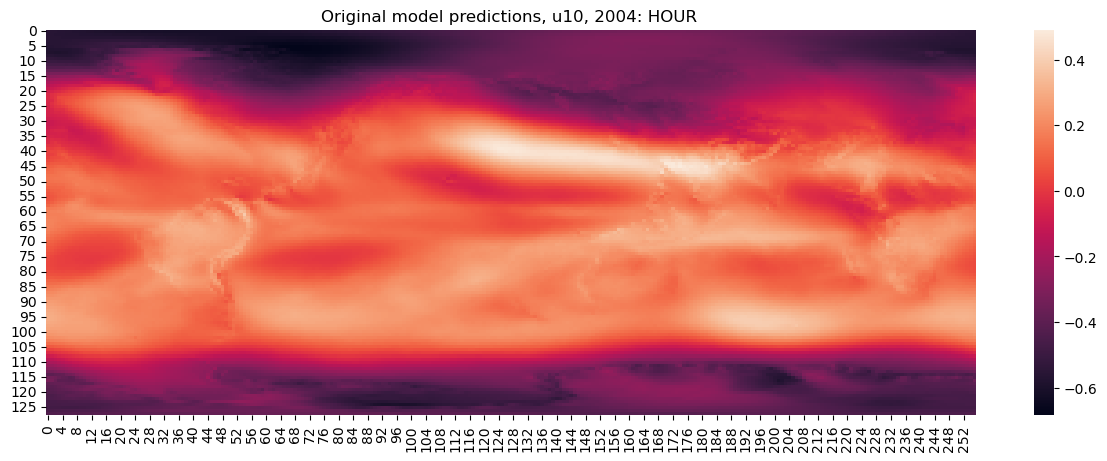

In [32]:
import seaborn as sns

fig, ax = plt.subplots(1, 1, figsize=(15, 5))

sns.heatmap(torch.flip(all_X, dims=(0, 1)), ax=ax)
ax.set_title('Original model predictions, u10, 2004: HOUR ')

plt.show()

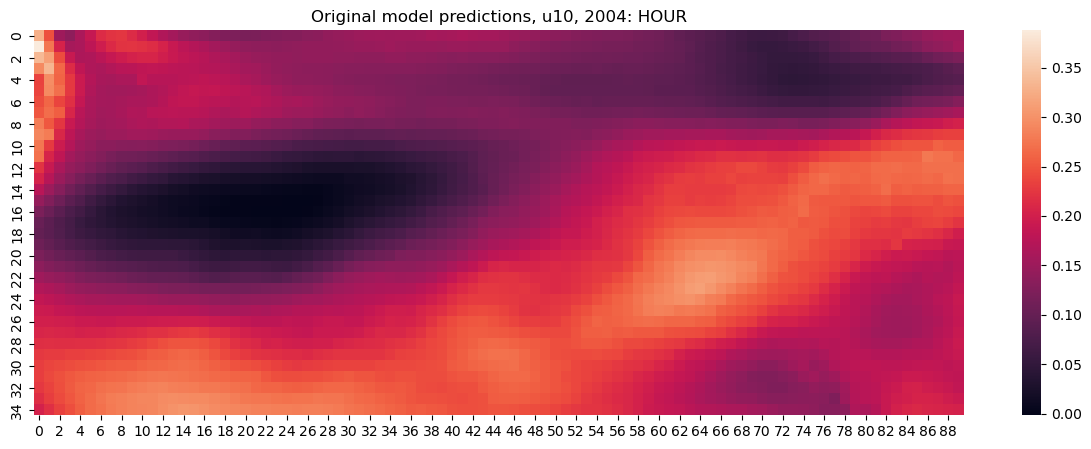

In [50]:
import seaborn as sns

fig, ax = plt.subplots(1, 1, figsize=(15, 5))

sns.heatmap(torch.flip(all_X, dims=(0, 1)), ax=ax)
ax.set_title('Original model predictions, u10, 2004: HOUR')

plt.show()

### Compare with original dataloader

In [ ]:
from Data.dataloader_weather import load_data

In [ ]:
data_root = '/home/fratnikov/weather_bench/'
prediction_horizone = 6

batch_size = 1 

dataloader_train, dataloader_vali, dataloader_test, mean, std = load_data(batch_size=batch_size,
                                                                          val_batch_size=batch_size,
                                                                          data_root=data_root,
                                                                          num_workers=1,
                                                                          data_split='1_40625',
                                                                          data_name='u10',
                                                                          train_time=['2015', '2015'],
                                                                          val_time=['2016', '2016'],
                                                                          test_time=['2017', '2018'],
                                                                          idx_in=[*range(0, 12)],
                                                                          idx_out=[*range(12, 12+prediction_horizone)],
                                                                          step=1,
                                                                          level=1,
                                                                          distributed=False, use_augment=False,
                                                                          use_prefetcher=False, drop_last=False)